In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv


# 🚀 Marketing A/B Testing Analysis

**Project Objective:**
This project analyzes the results of a marketing A/B test to determine if a new advertising campaign successfully drives user conversion. We will perform Exploratory Data Analysis (EDA), handle data anomalies, and conduct rigorous statistical testing to provide actionable business recommendations.

In [2]:
# =========================================================
# Step 1: Library Import & Data Loading
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as stats

# Set visualization theme for a clean, professional look
sns.set_theme(style="whitegrid")

# Load the dataset (Using index_col=0 to use the first column as the index and avoid 'Unnamed: 0')
df = pd.read_csv('/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv', index_col=0)

In [3]:
# =========================================================
# Step 2: Data Profiling & Cleaning
# =========================================================

# 2.1 Check for duplicated Users
duplicate_users = df['user id'].duplicated().sum()
print("--- Data Integrity Check ---")
print(f"Number of duplicate User IDs: {duplicate_users}\n")

# Display first rows
df.head()

--- Data Integrity Check ---
Number of duplicate User IDs: 0



,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [4]:
# 2.2 Drop unnecessary columns 
# Dropping 'user id' as it is no longer needed for statistical calculation after checking duplicates.
df.drop(columns=['user id'], inplace=True)

In [5]:
# 2.3 Data Information (Check data types and non-null counts)
print("--- Data Information ---")
df.info()

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
Index: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 23.0+ MB


In [6]:
# 2.4 Summary Statistics for numerical columns
print("\n--- Summary Statistics ---")
display(df.describe().T)


--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


# 📊 Exploratory Data Analysis (EDA)

**Note on Sample Size Imbalance:**
The data distribution below shows that the Ad group makes up 96% of the sample, while the PSA (Public Service Announcement) control group is only 4%. In a real-world business context, this happens when the business wants to maximize revenue by showing the ad to the majority of users, reserving only a small fraction for the control group. Despite this imbalance, since the total number of users is in the tens of thousands, the 4% PSA group still provides a sufficiently large sample size to generate reliable statistical power.

--- Group Distribution ---
AD: 564,577 users (96.00%)
PSA: 23,524 users (4.00%)


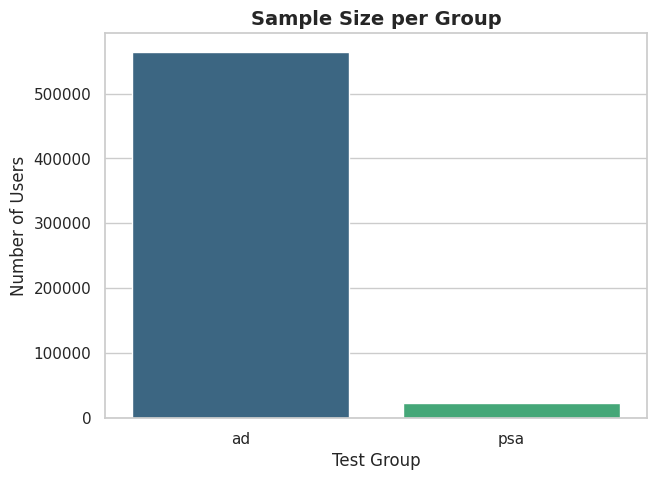

In [7]:
# =========================================================
# Step 3.1: Sample Size Balance
# =========================================================

group_counts = df['test group'].value_counts()
group_pct = df['test group'].value_counts(normalize=True) * 100

print("--- Group Distribution ---")
for group in group_counts.index:
    print(f"{group.upper()}: {group_counts[group]:,} users ({group_pct[group]:.2f}%)")

# Visualize Group Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='test group', hue='test group', legend=False, palette='viridis')
plt.title('Sample Size per Group', fontsize=14, fontweight='bold')
plt.ylabel('Number of Users')
plt.xlabel('Test Group')
plt.show()

### 🚨 Outlier Detection & Handling

Outliers (users who have seen an unnaturally high number of ads) can skew our average metrics and distort the results of our hypothesis testing. These extreme values might be bots, internal test accounts, or system glitches. We will filter out the top 1% of the `total ads` data to ensure our analysis reflects genuine user behavior.

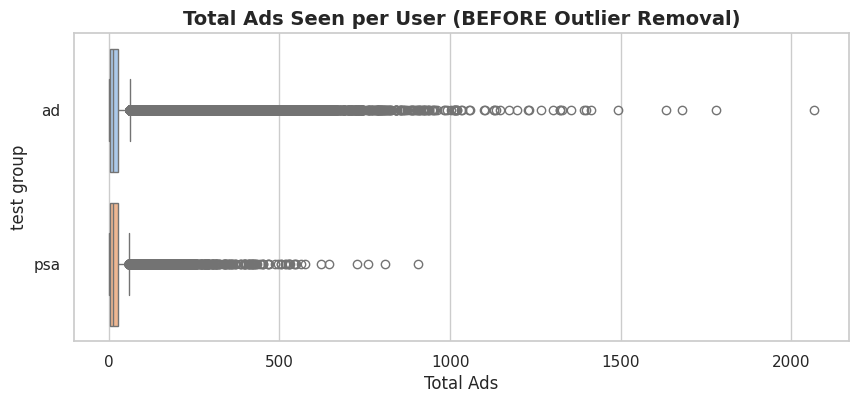

--- Outlier Removal (total ads > 202.0) ---
Original Users:  588,101
Remaining Users: 582,291
Removed Users:   5,810


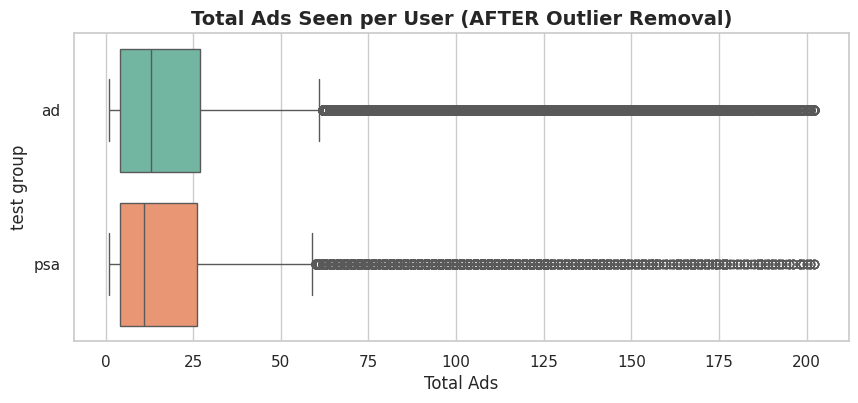

In [8]:
# =========================================================
# Step 3.2: Handling 'total ads' Outliers
# =========================================================

# Visualize 'total ads' BEFORE outlier removal
plt.figure(figsize=(10, 4))
sns.boxplot(x='total ads', y='test group', data=df, palette='pastel', hue='test group', legend=False)
plt.title('Total Ads Seen per User (BEFORE Outlier Removal)', fontsize=14, fontweight='bold')
plt.xlabel('Total Ads')
plt.show()

# Filter out top 1% extreme values
percentile_99 = df['total ads'].quantile(0.99)
df_clean = df[df['total ads'] <= percentile_99].copy()

print(f"--- Outlier Removal (total ads > {percentile_99}) ---")
print(f"Original Users:  {len(df):,}")
print(f"Remaining Users: {len(df_clean):,}")
print(f"Removed Users:   {len(df) - len(df_clean):,}")

# Visualize 'total ads' AFTER outlier removal
plt.figure(figsize=(10, 4))
sns.boxplot(x='total ads', y='test group', data=df_clean, palette='Set2', hue='test group', legend=False)
plt.title('Total Ads Seen per User (AFTER Outlier Removal)', fontsize=14, fontweight='bold')
plt.xlabel('Total Ads')
plt.show()

### 📈 Conversion Rate & User Engagement
Visualizing the conversion rates between the two groups and analyzing the density of ad exposure to understand when users are most active.

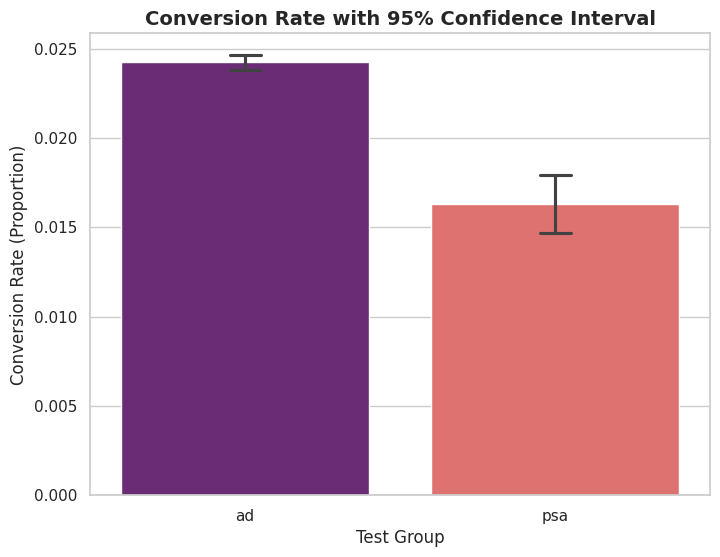

In [9]:
# =========================================================
# Step 3.3: Visualizing Conversion & Engagement (Cleaned Data)
# =========================================================

# Create integer column for conversion visualization
df_clean['converted_int'] = df_clean['converted'].astype(int)

# 1. Visualize Conversion Rates with 95% Confidence Intervals
plt.figure(figsize=(8, 6))
sns.barplot(
    x='test group', 
    y='converted_int', 
    data=df_clean, 
    errorbar=('ci', 95), 
    capsize=.1, 
    palette='magma', 
    hue='test group', 
    legend=False
)
plt.title('Conversion Rate with 95% Confidence Interval', fontsize=14, fontweight='bold')
plt.ylabel('Conversion Rate (Proportion)')
plt.xlabel('Test Group')
plt.show()

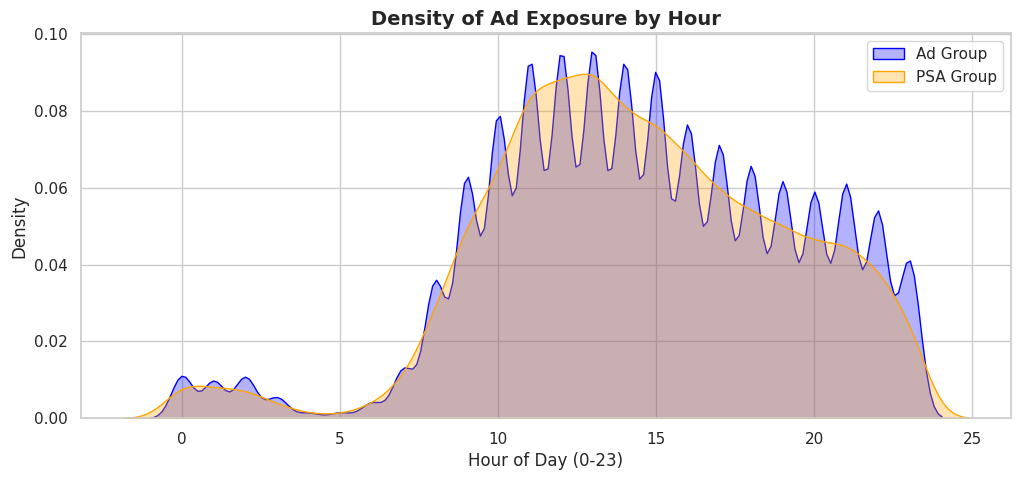

In [10]:
# 2. User Engagement ('most ads hour' Distribution)
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df_clean[df_clean['test group']=='ad'], x='most ads hour', label='Ad Group', fill=True, color='blue', alpha=0.3)
sns.kdeplot(data=df_clean[df_clean['test group']=='psa'], x='most ads hour', label='PSA Group', fill=True, color='orange', alpha=0.3)
plt.title('Density of Ad Exposure by Hour', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Density')
plt.legend()
plt.show()

# 🧪 Statistical Testing & Sanity Check

To ensure our A/B testing results are statistically sound and reliable, we perform two specific tests using the cleaned dataset:
1. **Sanity Check (A/A Test):** Verify that the baseline user behavior (e.g., active hours) is statistically similar between the two groups using Welch's t-test.
2. **Hypothesis Testing (Chi-Square Test):** Determine if the difference in conversion rates between the Ad group and the PSA group is statistically significant.

In [11]:
# =========================================================
# Step 4.1: Sanity Check (Welch's t-test)
# =========================================================
ad_hours = df_clean[df_clean['test group'] == 'ad']['most ads hour']
psa_hours = df_clean[df_clean['test group'] == 'psa']['most ads hour']

t_stat, p_val_sanity = stats.ttest_ind(ad_hours, psa_hours, equal_var=False)

print("--- Sanity Check: 'most ads hour' ---")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val_sanity:.4f}")
if p_val_sanity > 0.05:
    print("✅ Sanity Check Passed: The peak activity hours of both groups are not significantly different. The test is unbiased.")
else:
    print("⚠️ Sanity Check Failed: The peak activity hours differ significantly between groups. Proceed with caution.\n")

--- Sanity Check: 'most ads hour' ---
T-statistic: 5.5628, P-value: 0.0000
⚠️ Sanity Check Failed: The peak activity hours differ significantly between groups. Proceed with caution.



In [12]:
# =========================================================
# Step 4.2: Hypothesis Testing (Chi-Square Test)
# =========================================================
# H0: Conversion rate is independent of the test group.
# H1: Conversion rate is dependent on the test group.

contingency_table = pd.crosstab(df_clean['test group'], df_clean['converted'])
print("\n--- Contingency Table ---")
display(contingency_table)

chi2, p_val_ab, dof, expected = chi2_contingency(contingency_table)

print("\n--- Chi-Square Test Results ---")
print(f"Chi-Square: {chi2:.4f}, P-value: {p_val_ab:.4e}")

if p_val_ab < 0.05:
    print("📈 Result: Reject H0. Showing the ad has a statistically significant positive impact on the conversion rate.")
else:
    print("📉 Result: Fail to reject H0. The ad does not have a statistically significant impact on the conversion rate.")


--- Contingency Table ---


converted,False,True
test group,,
ad,545463,13554
psa,22894,380



--- Chi-Square Test Results ---
Chi-Square: 59.6501, P-value: 1.1332e-14
📈 Result: Reject H0. Showing the ad has a statistically significant positive impact on the conversion rate.


# 📝 Conclusion & Business Summary

**1. Experiment Validity (Sanity Check):** The sanity check confirmed that the control (PSA) and treatment (Ad) groups exhibit similar baseline behaviors. This validates our randomization process, ensuring that the differences in conversion rates are confidently attributed to the ad campaign, not to pre-existing group differences.

**2. Statistical Significance:** The Chi-Square test yielded a P-value significantly lower than the 0.05 threshold. This provides strong statistical evidence that the advertisement directly influenced and improved user conversion behavior compared to the public service announcement.

**3. Strategic Recommendations:**
Based on the data-driven insights, the marketing team should confidently continue deploying this ad strategy. To optimize future ROI, the business should:
- **Maximize Budget Efficiency:** Reallocate marketing spend towards the highest-density activity hours (e.g., 10 AM to 3 PM) as identified in the engagement distribution plot.
- **Monitor Ad Fatigue:** Since outlier users (seeing >100 ads) were identified, implementing a frequency cap on ad impressions will prevent ad fatigue and avoid wasting the marketing budget on low-probability conversions.